# Phase 2 ML Pipeline (Player-Enhanced)

This notebook is the notebook version of `phase2_train_pipeline.py` with:
- multiple model comparison (XGBoost, Random Forest, Logistic Regression)
- preprocessing for categorical and numeric features
- overfitting/underfitting diagnostics
- live progress bar during training
- saved graphs, reports, and deployment artifacts

In [5]:
from __future__ import annotations

import json
import pickle
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

try:
    from tqdm.auto import tqdm
except Exception:
    class _TqdmFallback:
        def __init__(self, iterable, **kwargs):
            self.iterable = iterable

        def __iter__(self):
            return iter(self.iterable)

        def set_postfix_str(self, *args, **kwargs):
            return None

    def tqdm(iterable, **kwargs):
        return _TqdmFallback(iterable, **kwargs)

## 1) Config

Set paths and split strategy. By default, 2025 is used as holdout test year.

In [2]:
RANDOM_STATE = 42
INPUT_PATH = Path("IPL_Winner_Model_Dataset_With_Players.csv")
RESULTS_DIR = Path("phase_2_result")
ARTIFACTS_DIR = Path("phase_2_artifacts")
TEST_YEAR = 2025

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Input:", INPUT_PATH)
print("Results dir:", RESULTS_DIR)
print("Artifacts dir:", ARTIFACTS_DIR)

Input: IPL_Winner_Model_Dataset_With_Players.csv
Results dir: phase_2_result
Artifacts dir: phase_2_artifacts


## 2) Helper Functions

These are the same core functions from the Python script, adapted for notebook flow.

In [6]:
def _param_space_size(grid: dict[str, list[Any]]) -> int:
    size = 1
    for values in grid.values():
        size *= max(1, len(values))
    return size


def load_and_split(data_path: Path, test_year: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = pd.read_csv(data_path)
    if "Date" not in df.columns:
        raise ValueError("Input dataset must include Date column")

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date", "Match_Winner"]).copy()
    df = df.sort_values(["Date", "Match_ID"]).reset_index(drop=True)

    test_mask = df["Date"].dt.year == test_year
    if test_mask.sum() > 0:
        train_df = df.loc[~test_mask].copy()
        test_df = df.loc[test_mask].copy()
    else:
        split_idx = int(len(df) * 0.8)
        train_df = df.iloc[:split_idx].copy()
        test_df = df.iloc[split_idx:].copy()

    if train_df.empty or test_df.empty:
        raise ValueError("Train/Test split failed. Check data and test-year.")

    return train_df, test_df


def build_preprocessor(X: pd.DataFrame) -> tuple[ColumnTransformer, list[str], list[str]]:
    categorical_cols = [c for c in X.columns if X[c].dtype == "object"]
    numeric_cols = [c for c in X.columns if c not in categorical_cols]

    cat_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
        ]
    )

    num_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", cat_pipe, categorical_cols),
            ("num", num_pipe, numeric_cols),
        ],
        remainder="drop",
    )
    return preprocessor, categorical_cols, numeric_cols


def evaluate_model(
    model: Pipeline,
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    X_test: pd.DataFrame,
    y_test: np.ndarray,
) -> dict[str, float]:
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    out = {
        "train_accuracy": float(accuracy_score(y_train, train_pred)),
        "test_accuracy": float(accuracy_score(y_test, test_pred)),
        "train_balanced_accuracy": float(balanced_accuracy_score(y_train, train_pred)),
        "test_balanced_accuracy": float(balanced_accuracy_score(y_test, test_pred)),
        "train_f1_weighted": float(f1_score(y_train, train_pred, average="weighted", zero_division=0)),
        "test_f1_weighted": float(f1_score(y_test, test_pred, average="weighted", zero_division=0)),
        "test_f1_macro": float(f1_score(y_test, test_pred, average="macro", zero_division=0)),
        "test_precision_weighted": float(precision_score(y_test, test_pred, average="weighted", zero_division=0)),
        "test_recall_weighted": float(recall_score(y_test, test_pred, average="weighted", zero_division=0)),
    }
    out["fit_gap_weighted_f1"] = out["train_f1_weighted"] - out["test_f1_weighted"]
    return out


def fit_models_with_progress(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    X_test: pd.DataFrame,
    y_test: np.ndarray,
) -> tuple[dict[str, Any], dict[str, dict[str, float]]]:
    preprocessor, _, _ = build_preprocessor(X_train)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    pipelines: dict[str, tuple[Pipeline, dict[str, list[Any]]]] = {
        "xgboost": (
            Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    (
                        "model",
                        XGBClassifier(
                            objective="multi:softprob",
                            eval_metric="mlogloss",
                            random_state=RANDOM_STATE,
                            n_jobs=-1,
                        ),
                    ),
                ]
            ),
            {
                "model__n_estimators": [180, 240],
                "model__max_depth": [4, 6],
                "model__learning_rate": [0.05, 0.08],
                "model__subsample": [0.8, 1.0],
                "model__colsample_bytree": [0.7, 1.0],
                "model__reg_lambda": [2.0, 5.0],
                "model__min_child_weight": [3, 5],
            },
        ),
        "random_forest": (
            Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    (
                        "model",
                        RandomForestClassifier(
                            random_state=RANDOM_STATE,
                            n_jobs=-1,
                            class_weight="balanced_subsample",
                        ),
                    ),
                ]
            ),
            {
                "model__n_estimators": [300, 450],
                "model__max_depth": [12, 18, None],
                "model__min_samples_leaf": [1, 2, 4],
                "model__min_samples_split": [2, 5],
                "model__max_features": ["sqrt", "log2", None],
            },
        ),
        "logistic_regression": (
            Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    (
                        "model",
                        LogisticRegression(
                            max_iter=1500,
                            class_weight="balanced",
                            n_jobs=-1,
                            random_state=RANDOM_STATE,
                        ),
                    ),
                ]
            ),
            {
                "model__C": [0.3, 0.7, 1.0, 1.5],
            },
        ),
    }

    best_models: dict[str, Any] = {}
    metrics: dict[str, dict[str, float]] = {}

    model_items = list(pipelines.items())
    pbar = tqdm(model_items, total=len(model_items), desc="Training models", unit="model")

    for model_name, (pipe, grid) in pbar:
        pbar.set_postfix_str(model_name)
        n_iter = min(8, _param_space_size(grid))
        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=grid,
            n_iter=n_iter,
            scoring="f1_weighted",
            cv=cv,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            refit=True,
            verbose=0,
        )
        search.fit(X_train, y_train)

        best_pipe = search.best_estimator_
        model_metrics = evaluate_model(best_pipe, X_train, y_train, X_test, y_test)
        model_metrics["best_cv_weighted_f1"] = float(search.best_score_)

        best_models[model_name] = {
            "pipeline": best_pipe,
            "best_params": search.best_params_,
        }
        metrics[model_name] = model_metrics

    return best_models, metrics


def save_comparison_plots(metrics_df: pd.DataFrame, out_dir: Path) -> None:
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(9, 5))
    m = metrics_df.sort_values("test_f1_weighted", ascending=False)
    ax = sns.barplot(
        data=m,
        x="model",
        y="test_f1_weighted",
        hue="model",
        palette="Set2",
        legend=False,
    )
    ax.set_title("Phase 2 Model Comparison (Test Weighted F1)")
    ax.set_xlabel("Model")
    ax.set_ylabel("Weighted F1")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(out_dir / "model_comparison_test_f1.png", dpi=150)
    plt.close()

    plt.figure(figsize=(9, 5))
    gap_df = metrics_df.copy()
    gap_df["is_overfit"] = gap_df["fit_gap_weighted_f1"] > 0.10
    ax = sns.barplot(data=gap_df, x="model", y="fit_gap_weighted_f1", hue="is_overfit", palette="coolwarm")
    ax.set_title("Overfitting Check (Train-Test Weighted F1 Gap)")
    ax.set_xlabel("Model")
    ax.set_ylabel("Gap")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(out_dir / "overfit_gap_comparison.png", dpi=150)
    plt.close()

## 3) Train, Compare, Diagnose

This cell runs the full training flow and saves artifacts/results exactly like the script.

In [7]:
train_df, test_df = load_and_split(INPUT_PATH, test_year=TEST_YEAR)

DROP_COLS = ["Match_Winner", "Match_ID", "Date"]
if "Teams" in train_df.columns:
    DROP_COLS.append("Teams")

feature_columns = [c for c in train_df.columns if c not in DROP_COLS]
X_train = train_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

y_train_raw = train_df["Match_Winner"].astype(str).values
y_test_raw = test_df["Match_Winner"].astype(str).values

label_encoder = LabelEncoder()
label_encoder.fit(np.concatenate([y_train_raw, y_test_raw]))
y_train = label_encoder.transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

best_models, metrics = fit_models_with_progress(X_train, y_train, X_test, y_test)

metrics_df = pd.DataFrame.from_dict(metrics, orient="index").reset_index(names=["model"])
metrics_df = metrics_df.sort_values("test_f1_weighted", ascending=False).reset_index(drop=True)

best_model_name = str(metrics_df.loc[0, "model"])
best_model_bundle = best_models[best_model_name]
best_model_pipeline = best_model_bundle["pipeline"]

y_pred_best = best_model_pipeline.predict(X_test)

labels = list(range(len(label_encoder.classes_)))
report = classification_report(
    y_test,
    y_pred_best,
    labels=labels,
    target_names=label_encoder.classes_.tolist(),
    zero_division=0,
    output_dict=True,
)

save_comparison_plots(metrics_df, RESULTS_DIR)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    labels=labels,
    display_labels=label_encoder.classes_,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "best_model_confusion_matrix.png", dpi=150)
plt.close()

model_obj = best_model_pipeline.named_steps["model"]
if hasattr(model_obj, "feature_importances_"):
    preprocessor = best_model_pipeline.named_steps["preprocessor"]
    feat_names = preprocessor.get_feature_names_out()
    importances = np.asarray(model_obj.feature_importances_)
    if len(importances) == len(feat_names):
        fi_df = pd.DataFrame({"feature": feat_names, "importance": importances})
        fi_df = fi_df.sort_values("importance", ascending=False).head(20)
        plt.figure(figsize=(10, 7))
        sns.barplot(
            data=fi_df,
            y="feature",
            x="importance",
            hue="feature",
            palette="viridis",
            legend=False,
        )
        plt.title(f"Top 20 Feature Importances - {best_model_name}")
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / "best_model_top20_feature_importance.png", dpi=150)
        plt.close()

metrics_df.to_csv(RESULTS_DIR / "model_comparison_metrics.csv", index=False)

overfit_flags = {}
for _, r in metrics_df.iterrows():
    gap = float(r["fit_gap_weighted_f1"])
    tf1 = float(r["train_f1_weighted"])
    vf1 = float(r["test_f1_weighted"])
    if gap > 0.12:
        status = "overfitting_risk"
    elif tf1 < 0.50 and vf1 < 0.50:
        status = "underfitting_risk"
    else:
        status = "balanced"
    overfit_flags[str(r["model"])] = {
        "status": status,
        "fit_gap_weighted_f1": round(gap, 4),
        "train_f1_weighted": round(tf1, 4),
        "test_f1_weighted": round(vf1, 4),
    }

metadata = {
    "train_file": str(INPUT_PATH),
    "train_size": int(len(train_df)),
    "test_size": int(len(test_df)),
    "test_year": int(TEST_YEAR),
    "feature_count": int(len(feature_columns)),
    "feature_columns": feature_columns,
    "models_evaluated": metrics_df["model"].tolist(),
    "model_metrics": metrics,
    "best_model": best_model_name,
    "best_model_params": best_model_bundle["best_params"],
    "best_model_test_metrics": metrics[best_model_name],
    "fit_diagnostics": overfit_flags,
}

bundle = {
    "model_pipeline": best_model_pipeline,
    "label_encoder": label_encoder,
    "feature_columns": feature_columns,
    "metadata": metadata,
}

joblib.dump(bundle, ARTIFACTS_DIR / "phase2_ipl_winner_best_pipeline.joblib")
with (ARTIFACTS_DIR / "phase2_ipl_winner_best_pipeline.pkl").open("wb") as f:
    pickle.dump(bundle, f)
with (ARTIFACTS_DIR / "phase2_model_metadata.json").open("w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)
with (RESULTS_DIR / "best_model_classification_report.json").open("w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

sample_payload = X_test.iloc[0].to_dict()
with (RESULTS_DIR / "sample_prediction_payload.json").open("w", encoding="utf-8") as f:
    json.dump(sample_payload, f, indent=2)

print(f"Saved results to: {RESULTS_DIR}")
print(f"Saved artifacts to: {ARTIFACTS_DIR}")
print(f"Best model: {best_model_name}")
print(
    "Best model test metrics: "
    + json.dumps(
        {
            "accuracy": round(metrics[best_model_name]["test_accuracy"], 4),
            "f1_weighted": round(metrics[best_model_name]["test_f1_weighted"], 4),
            "f1_macro": round(metrics[best_model_name]["test_f1_macro"], 4),
        }
    )
)

metrics_df

Saved results to: phase_2_result
Saved artifacts to: phase_2_artifacts
Best model: random_forest
Best model test metrics: {"accuracy": 0.5135, "f1_weighted": 0.4882, "f1_macro": 0.4648}


,model,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy,train_f1_weighted,test_f1_weighted,test_f1_macro,test_precision_weighted,test_recall_weighted,fit_gap_weighted_f1,best_cv_weighted_f1
0,random_forest,0.740260,0.513514,0.804599,0.506979,0.732036,0.488204,0.464840,0.519198,0.513514,0.243832,0.512675
1,xgboost,0.998918,0.486486,0.995098,0.459183,0.998904,0.484695,0.432135,0.524828,0.486486,0.514210,0.498794
2,logistic_regression,1.000000,0.418919,1.000000,0.447383,1.000000,0.393999,0.382525,0.424411,0.418919,0.606001,0.495547


## 4) Visual Review

Quickly inspect the generated plots and saved metadata.

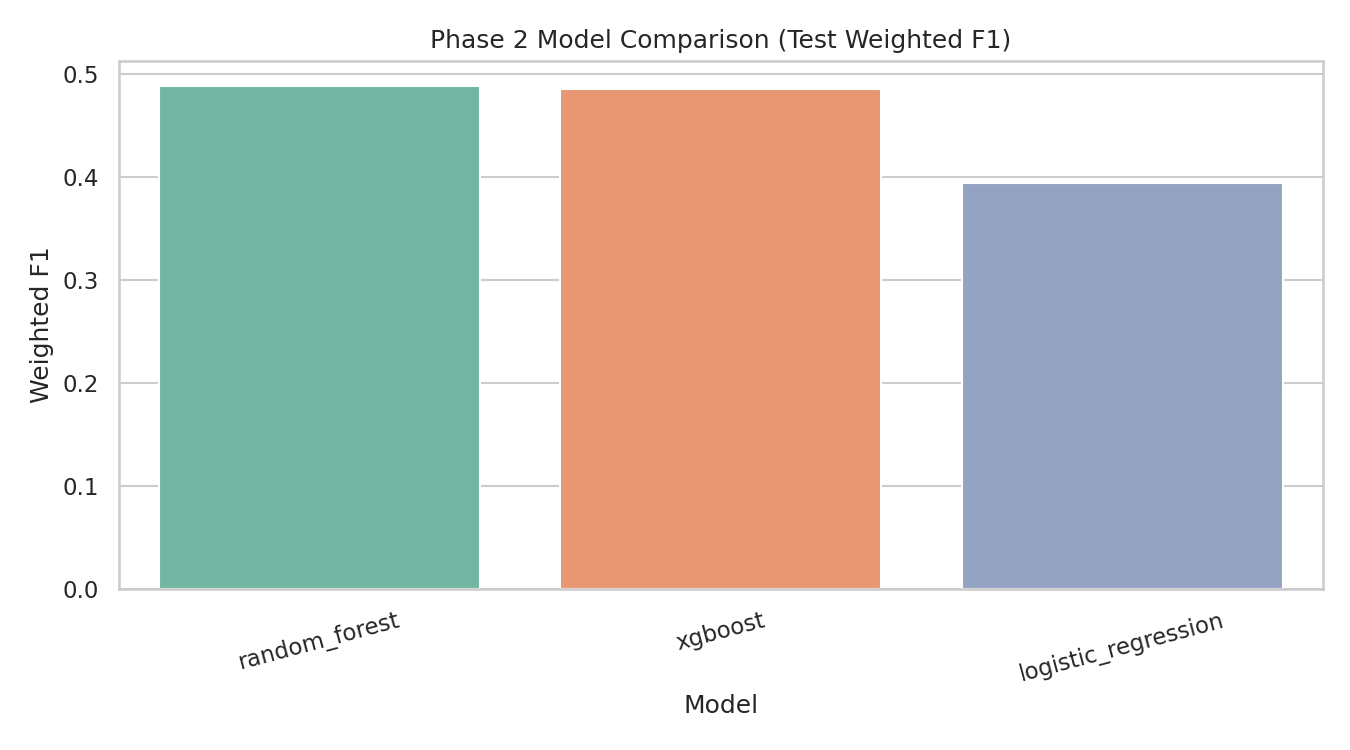

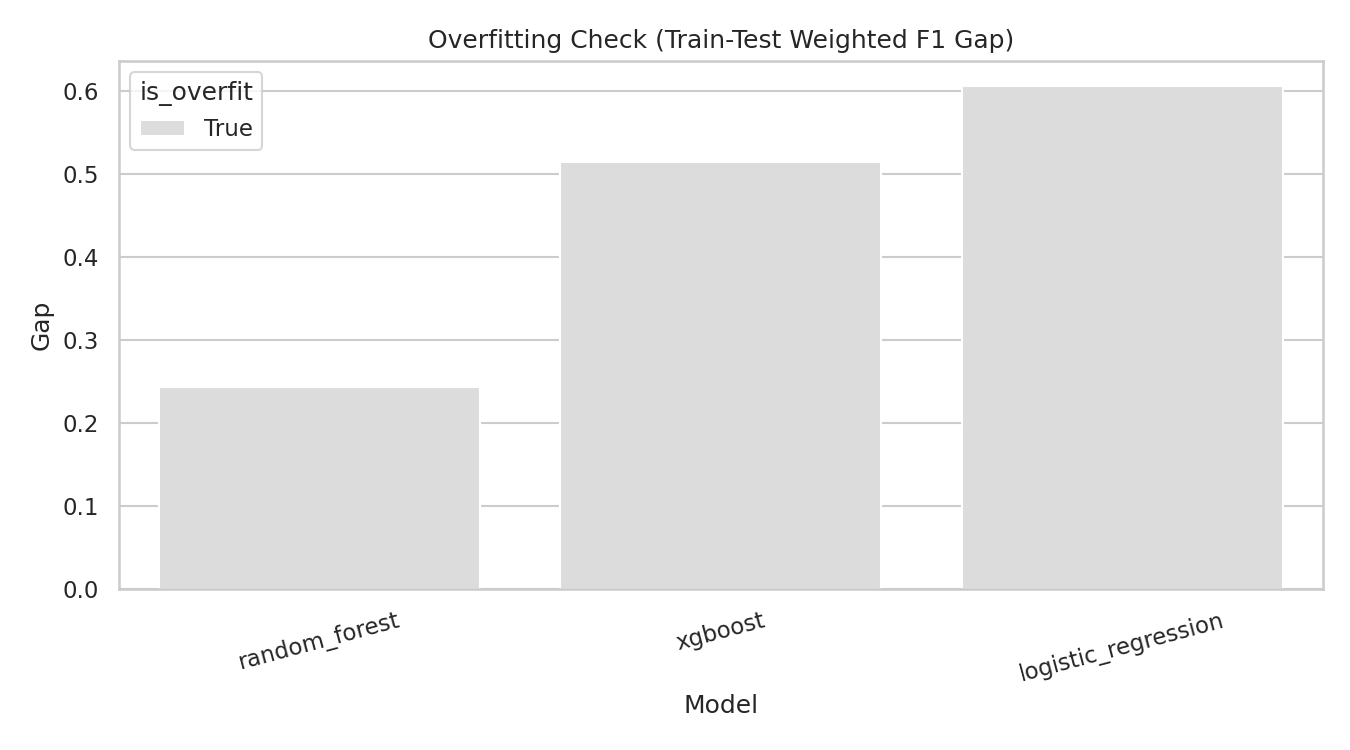

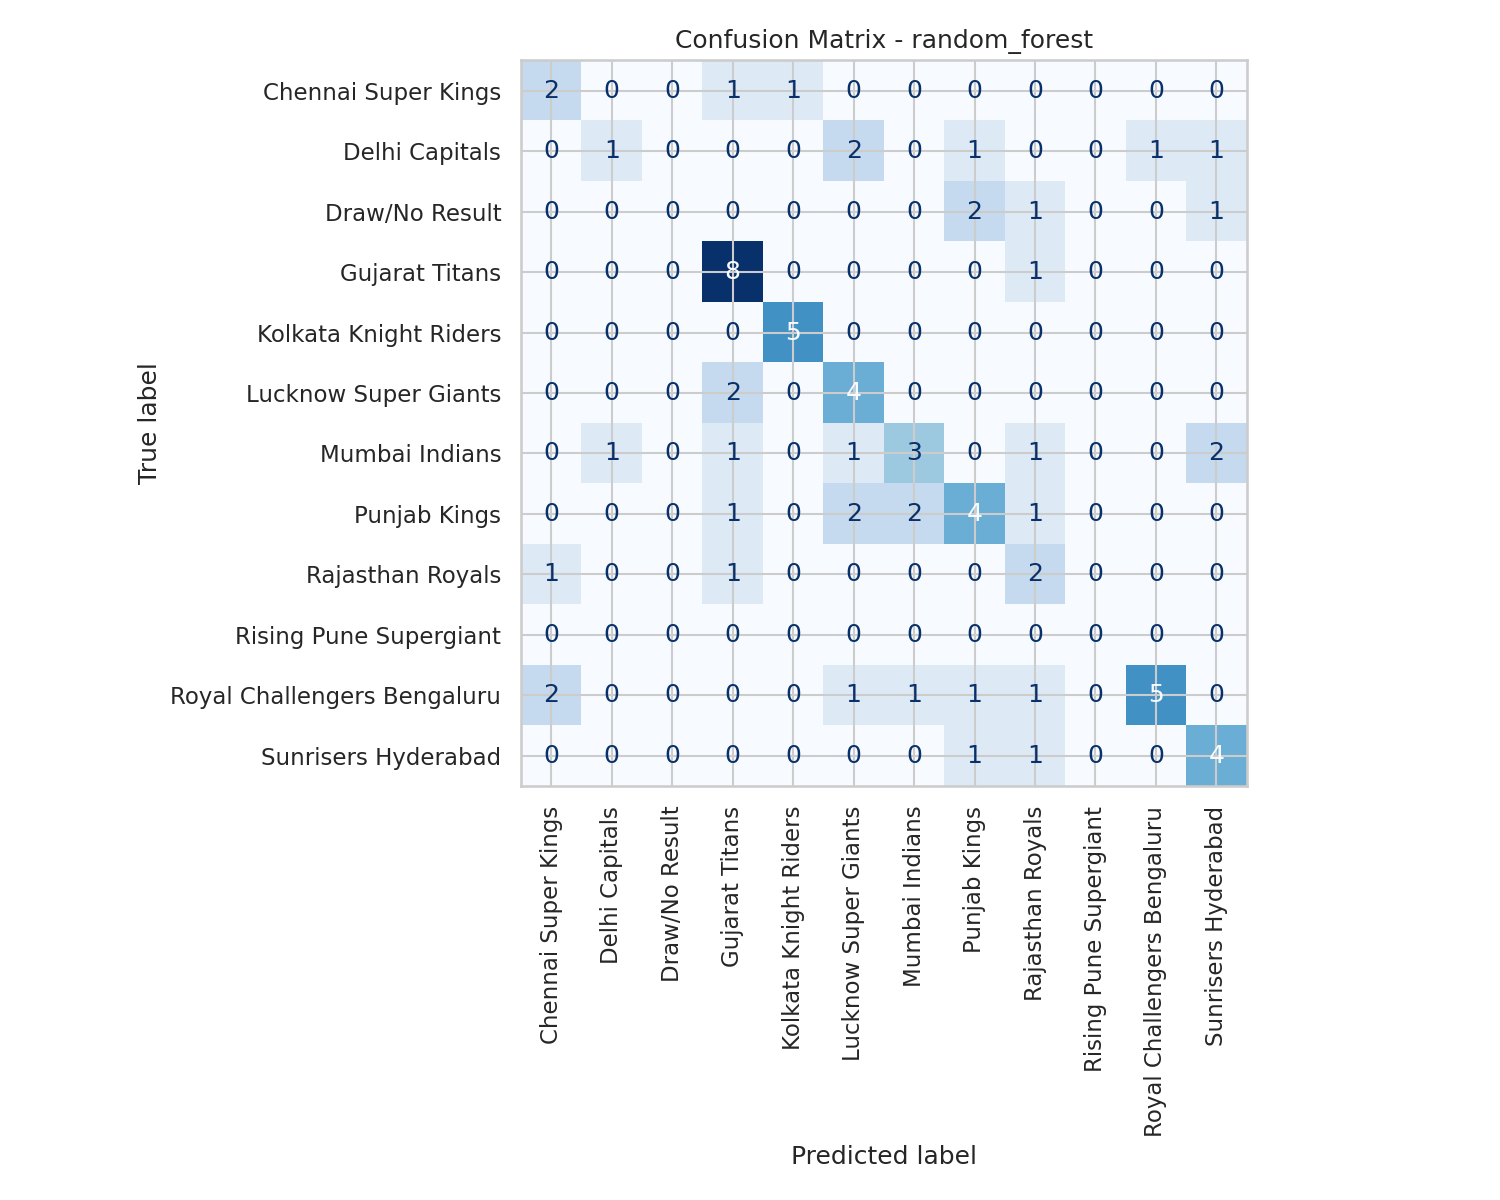

Best model: random_forest
Best model params: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 12}


{'train_accuracy': 0.7402597402597403,
 'test_accuracy': 0.5135135135135135,
 'train_balanced_accuracy': 0.8045993771584867,
 'test_balanced_accuracy': 0.5069788797061524,
 'train_f1_weighted': 0.7320358697423173,
 'test_f1_weighted': 0.48820434055997397,
 'test_f1_macro': 0.4648397598097178,
 'test_precision_weighted': 0.5191977691977693,
 'test_recall_weighted': 0.5135135135135135,
 'fit_gap_weighted_f1': 0.2438315291823433,
 'best_cv_weighted_f1': 0.5126749614230485}

In [8]:
display(Image(filename=str(RESULTS_DIR / "model_comparison_test_f1.png")))
display(Image(filename=str(RESULTS_DIR / "overfit_gap_comparison.png")))
display(Image(filename=str(RESULTS_DIR / "best_model_confusion_matrix.png")))

meta = json.loads((ARTIFACTS_DIR / "phase2_model_metadata.json").read_text(encoding="utf-8"))
print("Best model:", meta["best_model"])
print("Best model params:", meta["best_model_params"])
meta["best_model_test_metrics"]